In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

CLINICIAN sentiment score mean: 0.410834705882353 std: 0.4489380724892759
PATIENT sentiment score mean: 0.22237438423645323 std: 0.5064684776425228


C:\Users\changcambo\AppData\Local\Temp\ipykernel_30660\364674366.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['topic'] = df_clean['topic'].astype(str)


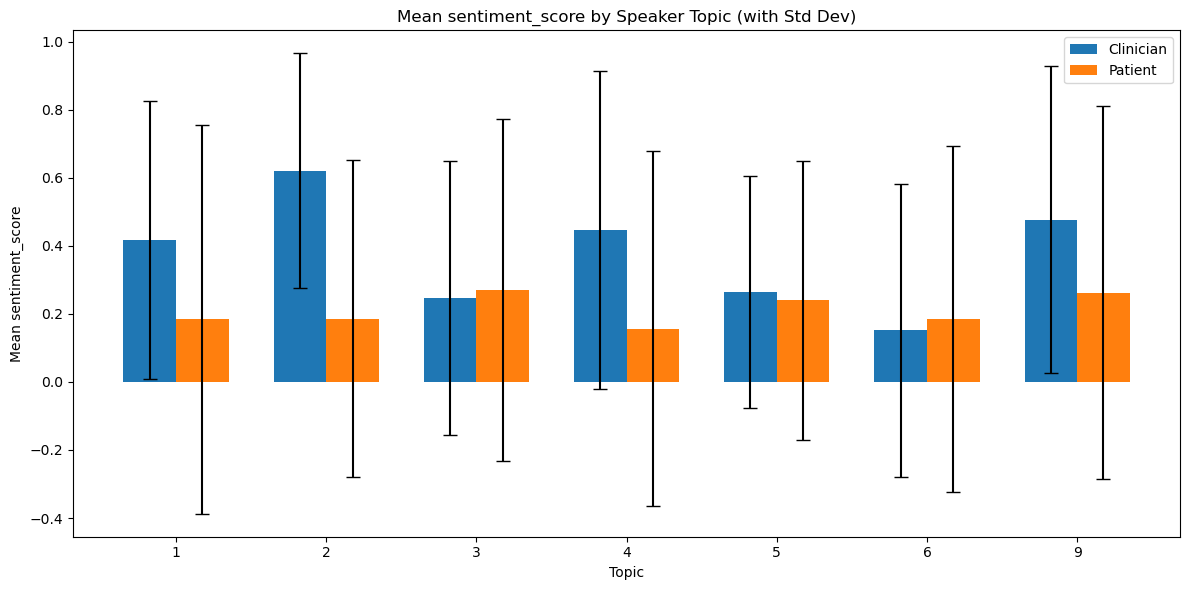

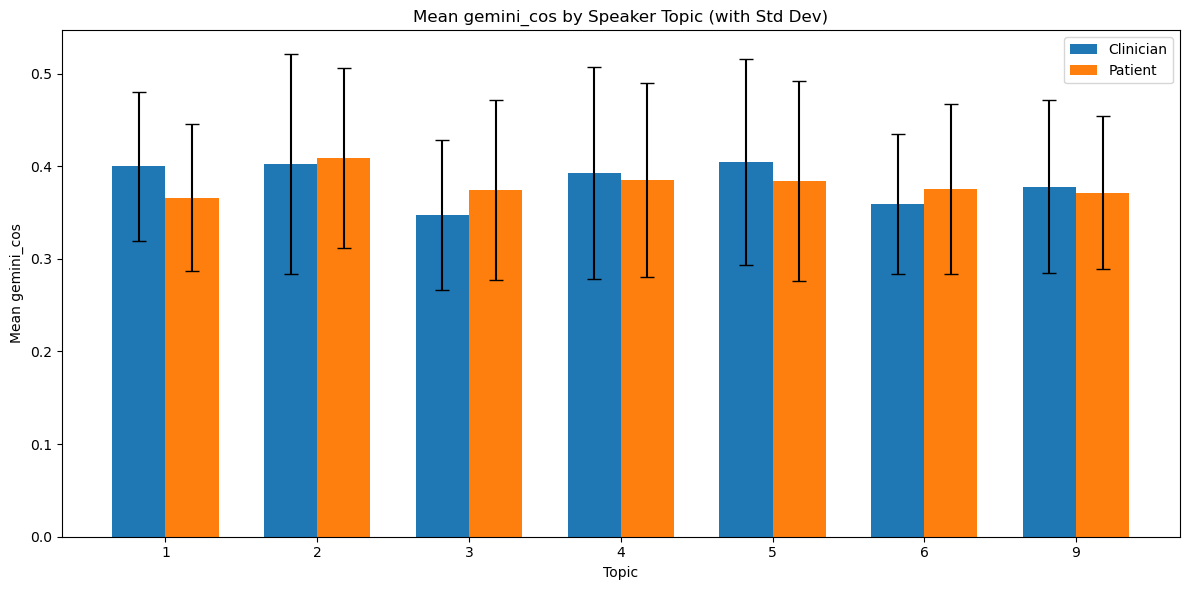

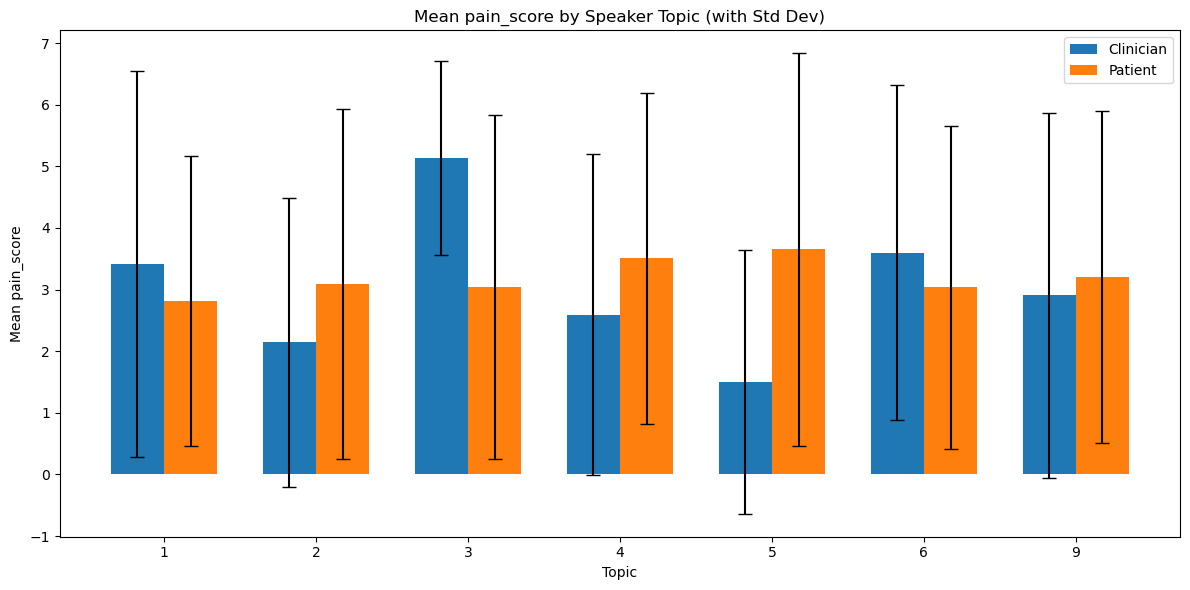

In [8]:
# Load the dataset
file_path = '10tp_cutoffline_0.85.csv'
df = pd.read_csv(file_path)

# Drop rows with missing topic, speaker, or sentiment_score
df_clean = df.dropna(subset=['topic', 'Speaker', 'sentiment_score'])
df_clinician = df_clean[df_clean['Speaker'] == 'CLINICIAN']
df_patient = df_clean[df_clean['Speaker'] == 'PATIENT']
print(f'CLINICIAN sentiment score mean: {df_clinician["sentiment_score"].mean()} std: {df_clinician["sentiment_score"].std()}')
print(f'PATIENT sentiment score mean: {df_patient["sentiment_score"].mean()} std: {df_patient["sentiment_score"].std()}')

# Split multi-topic entries (like "1,2") into separate rows
df_clean['topic'] = df_clean['topic'].astype(str)
df_expanded = df_clean.assign(topic=df_clean['topic'].str.split(',')).explode('topic')
df_expanded['topic'] = df_expanded['topic'].astype(int)

def plot_topic_dist(score_col):
    # Group by topic and speaker, compute mean and std deviation
    summary = df_expanded.groupby(['topic', 'Speaker'])[score_col].agg(['mean', 'std']).reset_index()

    # Pivot to separate columns for Clinician and Patient
    summary_pivot = summary.pivot(index='topic', columns='Speaker', values=['mean', 'std'])
    summary_pivot.columns = [f'{stat}_{speaker}' for stat, speaker in summary_pivot.columns]
    summary_pivot.reset_index(inplace=True)

    filtered = summary_pivot.dropna(subset=['mean_CLINICIAN', 'mean_PATIENT'])
    # Extract standard deviation values for error bars
    clinician_means = filtered['mean_CLINICIAN']
    patient_means = filtered['mean_PATIENT']
    clinician_stds = filtered['std_CLINICIAN']
    patient_stds = filtered['std_PATIENT']

    # Plot with error bars (std deviation)
    plt.figure(figsize=(12, 6))
    index = range(len(filtered))
    bar_width = 0.35

    plt.bar([i - bar_width/2 for i in index], clinician_means, yerr=clinician_stds,
            width=bar_width, label='Clinician', capsize=5)
    plt.bar([i + bar_width/2 for i in index], patient_means, yerr=patient_stds,
            width=bar_width, label='Patient', capsize=5)

    # Labels and title
    plt.xlabel('Topic')
    plt.ylabel(f'Mean {score_col}')
    plt.title(f'Mean {score_col} by Speaker Topic (with Std Dev)')
    plt.xticks(index, filtered['topic'])
    plt.legend()
    plt.tight_layout()

    # Show the plot
    plt.show()

plot_topic_dist('sentiment_score')
plot_topic_dist('gemini_cos')
plot_topic_dist('pain_score')

In [ ]:
conv_lvl = pd.read_excel('R01 participants.xlsx',header=1)
conv_lvl = conv_lvl.dropna(subset=['Phone'])
conv_lvl['name'] = conv_lvl['First name'] + ' ' + conv_lvl['Last name']
conv_lvl = conv_lvl.rename(columns={'OVERALL': 'PATIENT SATISFACTION','OVERALL.1': 'CLINICIAN SATISFACTION'})
print(conv_lvl.shape)
print(conv_lvl.columns)
conv_lvl_f = conv_lvl[['name','PATIENT SATISFACTION','CLINICIAN SATISFACTION']].copy()
transscipt = pd.read_excel('transcript analysis.xlsx')

(41, 89)
Index(['Record ID', 'First name', 'Last name', 'Pseudonym', 'Email', 'Phone',
       'Consent', 'Duration', 'Transcript?', 'Annotated?', 'Date of visit',
       'Time of rooming', 'Clinician seen', 'Cohort', '1) GC understands',
       '2) needed to know', '3) I felt better', '4) right length',
       '5) concerned', '6) valuable', 'PATIENT SATISFACTION', 'Reason', 'Pain',
       '1) understand', '2) worked together', '3) felt better',
       '4) right length.1', '5) concerned.1', '6) valuable.1',
       'CLINICIAN SATISFACTION', 'Indication', 'Date', 'Duration.1',
       'No. clips', 'Clip length', 'Alignment', 'LLM Alignment', 'NORMALIZED',
       'Sentiment', 'LLM Sentiment', 'NORMALIZED.1', 'Alignment.1',
       'LLM Alignment.1', 'NORMALIZED.2', 'Sentiment.1', 'LLM Sentiment.1',
       'NORMALIZED.3', 'Alignment.2', 'LLM Alignment.2', 'NORMALIZED.4',
       'Sentiment.2', 'LLM Sentiment.2', 'NORMALIZED.5', 'Alignment.3',
       'LLM Alignment.3', 'NORMALIZED.6', 'Sentimen

In [17]:
#conv_lvl_f.head()
transscipt = transscipt.dropna(subset=['pt name'])
name2id = transscipt[['pt name','sample_id']].drop_duplicates()
sampleid2score = name2id.merge(conv_lvl_f, left_on='pt name', right_on='name', how='left')
print(sampleid2score.shape)
print(sampleid2score.head())
sampleid2score.to_csv('sampleid2score.csv', index=False)

(40, 5)
          pt name  sample_id            name PATIENT SATISFACTION  \
0   Alicia Foster  240301_AF   Alicia Foster                   30   
1   Jennifer Zink  240228_JZ   Jennifer Zink                   30   
2    Nancy Laymon  240306_NL    Nancy Laymon                   30   
3     Emily Smith  240228_ES             NaN                  NaN   
4  Ashley Hammond  240308_AH  Ashley Hammond                   29   

  CLINICIAN SATISFACTION  
0                     23  
1                     29  
2                     22  
3                    NaN  
4                     28  
